In [23]:
# import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

## 手动实现

### 1.人工神经元

In [2]:
def neurons(X, w, b, act):
    z = torch.mm(X, w) + b
    return act(z)

### 2.激活函数

In [3]:
def sigmoid(x):
    return 1.0 / (1.0 + torch.exp(-x))


def fun_tanh(x):
    return (torch.exp(x) - torch.exp(-x)) / (torch.exp(x) + torch.exp(-x))


def fun_relu(x):
    return torch.where(x >= 0, x, torch.zeros_like(x))


def fun_leakyrelu(x, gamma=0.2):
    return torch.where(x > 0, x, gamma * x)


def fun_elu(x, gamma=0.2):
    return torch.where(x > 0, x, gamma * (torch.exp(x) - 1))


acts = {
    "sigmoid": sigmoid,
    "relu": fun_relu,
    "tanh": fun_tanh,
    "leakyrelu": lambda x: fun_leakyrelu(x, 0.2),
    "elu": lambda x: fun_elu(x, 0.2),
}

In [4]:
# 使用 PyTorch 官方激活函数测试手写实现
torch.manual_seed(42)

x = torch.randn(10) * 3
gamma = 0.2

tests = [
    ("Sigmoid", sigmoid(x), torch.sigmoid(x)),
    ("Tanh", fun_tanh(x), torch.tanh(x)),
    ("ReLU", fun_relu(x), F.relu(x)),
    ("LeakyReLU", fun_leakyrelu(x, gamma), F.leaky_relu(x, negative_slope=gamma)),
    ("ELU", fun_elu(x, gamma), F.elu(x, alpha=gamma)),
]

print("输入：")
print(x)

for name, manual_output, torch_output in tests:
    is_correct = torch.allclose(manual_output, torch_output, atol=1e-6, rtol=1e-5)

    max_error = torch.max(torch.abs(manual_output - torch_output)).item()

    print(f"\n{name}")
    print("手写结果：", manual_output)
    print("官方结果：", torch_output)
    print("是否一致：", is_correct)
    print("最大误差：", max_error)

输入：
tensor([ 1.0101,  0.3864,  0.7034,  0.6910, -3.3686, -0.5590,  6.6246, -1.9140,
         1.3850,  0.8021])

Sigmoid
手写结果： tensor([0.7330, 0.5954, 0.6689, 0.6662, 0.0333, 0.3638, 0.9987, 0.1285, 0.7998,
        0.6904])
官方结果： tensor([0.7330, 0.5954, 0.6689, 0.6662, 0.0333, 0.3638, 0.9987, 0.1285, 0.7998,
        0.6904])
是否一致： True
最大误差： 0.0

Tanh
手写结果： tensor([ 0.7658,  0.3683,  0.6065,  0.5986, -0.9976, -0.5072,  1.0000, -0.9574,
         0.8821,  0.6652])
官方结果： tensor([ 0.7658,  0.3683,  0.6065,  0.5986, -0.9976, -0.5072,  1.0000, -0.9574,
         0.8821,  0.6652])
是否一致： True
最大误差： 5.960464477539063e-08

ReLU
手写结果： tensor([1.0101, 0.3864, 0.7034, 0.6910, 0.0000, 0.0000, 6.6246, 0.0000, 1.3850,
        0.8021])
官方结果： tensor([1.0101, 0.3864, 0.7034, 0.6910, 0.0000, 0.0000, 6.6246, 0.0000, 1.3850,
        0.8021])
是否一致： True
最大误差： 0.0

LeakyReLU
手写结果： tensor([ 1.0101,  0.3864,  0.7034,  0.6910, -0.6737, -0.1118,  6.6246, -0.3828,
         1.3850,  0.8021])
官方结果： tensor([ 1.0101,  0

### 3.SGD

In [5]:
def SGD(params, lr):
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad

### 3.Dropout

In [6]:
def dropout_layer(X, dropout):
    assert 0.0 <= dropout <= 1.0

    if dropout == 0.0:
        return X

    if dropout == 1.0:
        return torch.zeros_like(X)

    # 以 1-dropout 的概率保留神经元
    mask = (torch.rand_like(X) > dropout).to(X.dtype)

    # 使用 inverted dropout 保持期望值不变
    return mask * X / (1.0 - dropout)

In [7]:
# ============================================================
# 简单测试Dropout
# ============================================================

X = torch.arange(1, 11, dtype=torch.float32)

print("原始输入：")
print(X)

print("\ndropout=0：")
manual_output = dropout_layer(X, 0.0)
torch_output = F.dropout(X, p=0.0, training=True)

print("手写结果：", manual_output)
print("官方结果：", torch_output)
print("测试通过：", torch.equal(manual_output, torch_output))


print("\ndropout=0.5：")

torch.manual_seed(42)
manual_output = dropout_layer(X, 0.5)

torch.manual_seed(42)
torch_output = F.dropout(X, p=0.5, training=True)

print("手写结果：", manual_output)
print("官方结果：", torch_output)
print("手写输出均值：", manual_output.mean().item())
print("官方输出均值：", torch_output.mean().item())


print("\ndropout=1：")
manual_output = dropout_layer(X, 1.0)
torch_output = F.dropout(X, p=1.0, training=True)

print("手写结果：", manual_output)
print("官方结果：", torch_output)
print("测试通过：", torch.equal(manual_output, torch_output))


# 使用大量数据检查Dropout的丢弃比例和期望
large_X = torch.ones(1_000_000)
dropout = 0.5

manual_output = dropout_layer(large_X, dropout)

zero_ratio = (manual_output == 0).float().mean().item()

print("\nDropout统计测试：")
print("设定丢弃率：", dropout)
print("实际丢弃率：", zero_ratio)
print("输入均值：", large_X.mean().item())
print("输出均值：", manual_output.mean().item())

原始输入：
tensor([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

dropout=0：
手写结果： tensor([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])
官方结果： tensor([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])
测试通过： True

dropout=0.5：
手写结果： tensor([ 2.,  4.,  0.,  8.,  0., 12.,  0., 16., 18.,  0.])
官方结果： tensor([ 2.,  4.,  6.,  8.,  0., 12.,  0.,  0., 18., 20.])
手写输出均值： 6.0
官方输出均值： 7.0

dropout=1：
手写结果： tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
官方结果： tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
测试通过： True

Dropout统计测试：
设定丢弃率： 0.5
实际丢弃率： 0.5006210207939148
输入均值： 1.0
输出均值： 0.9987580180168152


### 4.L2正则化

In [8]:
def l2_penalty(weights):
    penalty = torch.zeros((), device=weights[0].device)

    for weight in weights:
        penalty = penalty + torch.sum(weight**2)

    return penalty / 2


def make_l2_loss(base_loss_fn, params, lambd):
    weight_params = [p for p in params if p.ndim > 1]

    def loss_fn(y_hat, y):
        return base_loss_fn(y_hat, y) + lambd * l2_penalty(weight_params)

    return loss_fn

In [9]:
# ============================================================
# 简单测试L2 Penalty
# ============================================================

W1 = torch.tensor([
    [1.0, 2.0],
    [3.0, 4.0]
])

W2 = torch.tensor([
    [-1.0, 2.0]
])

manual_result = l2_penalty([W1, W2])

torch_result = (
    torch.sum(W1 ** 2)
    + torch.sum(W2 ** 2)
) / 2

print("\nL2 Penalty测试：")
print("W1：")
print(W1)

print("W2：")
print(W2)

print("手写结果：", manual_result.item())
print("PyTorch计算结果：", torch_result.item())

print(
    "测试通过：",
    torch.allclose(
        manual_result,
        torch_result
    )
)

# 期望值：
# (1² + 2² + 3² + 4² + (-1)² + 2²) / 2
# = (1 + 4 + 9 + 16 + 1 + 4) / 2
# = 17.5


L2 Penalty测试：
W1：
tensor([[1., 2.],
        [3., 4.]])
W2：
tensor([[-1.,  2.]])
手写结果： 17.5
PyTorch计算结果： 17.5
测试通过： True


### 5.网络定义

In [10]:
def init_linear(
    in_features, out_features, scale=0.01, device=None, dtype=torch.float32
):
    W = torch.randn(in_features, out_features, device=device, dtype=dtype) * scale
    b = torch.zeros(out_features, device=device, dtype=dtype)
    W.requires_grad_()
    b.requires_grad_()
    return W, b


class ManualMLP:
    def __init__(
        self,
        layer_sizes,
        hidden_act=fun_relu,
        dropout=0.0,
        scale=0.01,
    ):
        self.hidden_act = hidden_act
        self.dropout = dropout
        self.params = []

        for in_dim, out_dim in zip(layer_sizes[:-1], layer_sizes[1:]):
            W, b = init_linear(
                in_dim,
                out_dim,
                scale=scale,
            )
            self.params.extend([W, b])

    def __call__(self, X, training=True):
        H = X

        num_layers = len(self.params) // 2

        for layer_idx in range(num_layers - 1):
            W = self.params[2 * layer_idx]
            b = self.params[2 * layer_idx + 1]

            H = self.hidden_act(H @ W + b)

            if training and self.dropout > 0:
                H = dropout_layer(H, self.dropout)

        W = self.params[-2]
        b = self.params[-1]

        # 输出层不使用激活函数：
        # 回归：MSELoss
        # 二分类：BCEWithLogitsLoss
        # 多分类：CrossEntropyLoss
        return H @ W + b

## torch.nn实现

### 1.激活函数

In [11]:
def get_torch_activation(name):
    if name == "relu":
        return nn.ReLU()

    if name == "tanh":
        return nn.Tanh()

    if name == "sigmoid":
        return nn.Sigmoid()

    if name == "leakyrelu":
        return nn.LeakyReLU(negative_slope=0.2)

    if name == "elu":
        return nn.ELU(alpha=0.2)

    raise ValueError(f"未知激活函数：{name}")

### 2.网络定义

In [12]:
class TorchMLP(nn.Module):
    def __init__(self, layer_sizes, activation="relu", dropout=0.0):
        super().__init__()

        layers = []

        for i in range(len(layer_sizes) - 2):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i + 1]))
            layers.append(get_torch_activation(activation))

            if dropout > 0:
                layers.append(nn.Dropout(p=dropout))

        layers.append(nn.Linear(layer_sizes[-2], layer_sizes[-1]))

        self.net = nn.Sequential(*layers)

    def forward(self, X):
        return self.net(X)

## Infra

### 1.计算模型准确率

In [13]:
def evaluate_accuracy(data_iter, net, task_type):
    if task_type == "regression":
        raise ValueError("回归任务不使用accuracy，请使用MSE、RMSE或MAE")

    correct = 0
    sample_count = 0

    with torch.no_grad():
        for X, y in data_iter:
            y_hat = net(X)

            if task_type == "binary":
                # 单输出二分类
                scores = y_hat.reshape(-1)
                labels = y.reshape(-1).long()
                predictions = (scores >= 0).long()

            elif task_type == "multiclass":
                # 多分类
                predictions = y_hat.argmax(dim=1)
                labels = y.reshape(-1).long()

            else:
                raise ValueError(f"未知任务类型：{task_type}")

            correct += (predictions == labels).sum().item()

            sample_count += labels.shape[0]

    return correct / sample_count

### 2.数据集加载

#### 2.1回归

In [14]:
# ============================================================
# 1. 回归任务数据集
#
# 样本总数：10000
# 训练集：7000
# 测试集：3000
# 特征维度：500
#
# y = 0.028 + sum(0.0056 * x_i) + noise
# ============================================================


def load_regression_data(batch_size=32, noise_std=0.01, seed=42):
    generator = torch.Generator().manual_seed(seed)

    num_samples = 10000
    num_train = 7000
    num_features = 500

    # 生成特征
    X = torch.randn(num_samples, num_features, generator=generator)

    # 生成噪声
    noise = torch.randn(num_samples, 1, generator=generator) * noise_std

    # y = 0.028 + Σ(0.0056 * x_i) + noise
    y = 0.028 + 0.0056 * X.sum(dim=1, keepdim=True) + noise

    # 随机打乱数据
    indices = torch.randperm(num_samples, generator=generator)

    X = X[indices]
    y = y[indices]

    # 划分训练集和测试集
    X_train = X[:num_train]
    y_train = y[:num_train]

    X_test = X[num_train:]
    y_test = y[num_train:]

    train_dataset = TensorDataset(X_train, y_train)

    test_dataset = TensorDataset(X_test, y_test)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        generator=generator,
    )

    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False, num_workers=0
    )

    return train_loader, test_loader

#### 2.2二分类

In [15]:
# ============================================================
# 2. 二分类任务数据集
#
# 每个类别的数据集大小：10000
# 每个类别训练集：7000
# 每个类别测试集：3000
# 特征维度：200
#
# 类别0：N(-mean, std²)
# 类别1：N(+mean, std²)
#
# 合并后：
# 训练集大小：14000
# 测试集大小：6000
#
# 标签形状为 [N, 1]，适用于 BCEWithLogitsLoss
# ============================================================


def load_binary_classification_data(
    batch_size=32, class_mean=0.5, class_std=1.0, seed=42
):
    generator = torch.Generator().manual_seed(seed)

    samples_per_class = 10000
    train_per_class = 7000
    num_features = 200

    # 类别0：均值为 -class_mean
    X_class0 = (
        torch.randn(samples_per_class, num_features, generator=generator) * class_std
        - class_mean
    )

    y_class0 = torch.zeros(samples_per_class, 1, dtype=torch.float32)

    # 类别1：均值为 +class_mean
    X_class1 = (
        torch.randn(samples_per_class, num_features, generator=generator) * class_std
        + class_mean
    )

    y_class1 = torch.ones(samples_per_class, 1, dtype=torch.float32)

    # 每个类别分别划分训练集和测试集
    X0_train = X_class0[:train_per_class]
    y0_train = y_class0[:train_per_class]

    X0_test = X_class0[train_per_class:]
    y0_test = y_class0[train_per_class:]

    X1_train = X_class1[:train_per_class]
    y1_train = y_class1[:train_per_class]

    X1_test = X_class1[train_per_class:]
    y1_test = y_class1[train_per_class:]

    # 合并两个类别的训练数据
    X_train = torch.cat([X0_train, X1_train], dim=0)

    y_train = torch.cat([y0_train, y1_train], dim=0)

    # 合并两个类别的测试数据
    X_test = torch.cat([X0_test, X1_test], dim=0)

    y_test = torch.cat([y0_test, y1_test], dim=0)

    # 打乱训练集
    train_indices = torch.randperm(X_train.shape[0], generator=generator)

    X_train = X_train[train_indices]
    y_train = y_train[train_indices]

    # 打乱测试集
    test_indices = torch.randperm(X_test.shape[0], generator=generator)

    X_test = X_test[test_indices]
    y_test = y_test[test_indices]

    train_dataset = TensorDataset(X_train, y_train)

    test_dataset = TensorDataset(X_test, y_test)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        generator=generator,
    )

    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False, num_workers=0
    )

    return train_loader, test_loader

#### 2.3多分类

In [16]:
# ============================================================
# 3. MNIST 多分类任务数据集
#
# 训练集：60000
# 测试集：10000
# 图像大小：1 × 28 × 28
# 类别数：10
# ============================================================


def load_mnist_data(batch_size=32, data_root="../data"):
    transform = transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Lambda(lambda x: x.reshape(-1)),  # [1, 28, 28] -> [784]
        ]
    )

    train_dataset = datasets.MNIST(
        root=data_root,
        train=True,
        transform=transform,
        download=True,
    )

    test_dataset = datasets.MNIST(
        root=data_root,
        train=False,
        transform=transform,
        download=True,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )

    return train_loader, test_loader

### 3.训练主体

In [17]:
def zero_grad(params):
    for param in params:
        if param.grad is not None:
            param.grad.zero_()


def forward(net, X, implementation, training):
    """
    implementation:
        "manual": 手动实现的网络，要求支持net(X, training=True)
        "torch":  torch.nn.Module网络
    """

    if implementation == "manual":
        return net(X, training=training)

    if implementation == "torch":
        if training:
            net.train()
        else:
            net.eval()

        return net(X)

    raise ValueError("implementation只能是'manual'或'torch'")


def prepare_target(y_hat, y, task_type):
    """将标签整理成与损失函数匹配的形状和数据类型。"""

    if task_type == "regression":
        return y.to(y_hat.dtype).reshape_as(y_hat)

    if task_type == "binary":
        return y.to(y_hat.dtype).reshape_as(y_hat)

    if task_type == "multiclass":
        return y.long().reshape(-1)

    raise ValueError(f"未知任务类型：{task_type}")


def batch_correct(y_hat, y, task_type):
    """返回当前批次预测正确的样本数。"""

    if task_type == "regression":
        return 0

    if task_type == "binary":
        scores = y_hat.reshape(-1)
        labels = y.reshape(-1).long()
        predictions = (scores >= 0.0).long()

    elif task_type == "multiclass":
        labels = y.reshape(-1).long()
        predictions = y_hat.argmax(dim=1)

    else:
        raise ValueError(f"未知任务类型：{task_type}")

    return (predictions == labels).sum().item()


def evaluate_accuracy(data_iter, net, task_type, implementation):
    if task_type == "regression":
        raise ValueError("回归任务不使用accuracy，请使用MSE、RMSE或MAE")

    correct = 0
    sample_count = 0

    with torch.no_grad():
        for X, y in data_iter:
            y_hat = forward(net, X, implementation, training=False)

            correct += batch_correct(y_hat, y, task_type)

            sample_count += y.shape[0]

    return correct / sample_count


def evaluate_loss(data_iter, net, loss_fn, task_type, implementation):
    loss_sum = 0.0
    sample_count = 0

    with torch.no_grad():
        for X, y in data_iter:
            y_hat = forward(net, X, implementation, training=False)

            target = prepare_target(y_hat, y, task_type)

            batch_loss = loss_fn(y_hat, target)

            batch_size = y.shape[0]

            loss_sum += batch_loss.item() * batch_size

            sample_count += batch_size

    return loss_sum / sample_count


def train(
    net,
    train_iter,
    test_iter,
    loss_fn,
    num_epochs,
    task_type,
    implementation,
    params=None,
    lr=None,
    optimizer=None,
):
    """
    手动实现：
        implementation="manual"
        params=params
        lr=0.1
        optimizer=None

    torch.nn实现：
        implementation="torch"
        optimizer=optimizer
        params和lr无需传入
    """

    if implementation == "manual":
        if params is None or lr is None:
            raise ValueError("手动实现必须传入params和lr")

    if implementation == "torch":
        if optimizer is None:
            raise ValueError("torch.nn实现必须传入optimizer")

    history = {
        "train_loss": [],
        "test_loss": [],
        "train_accuracy": [],
        "test_accuracy": [],
    }

    for epoch in range(num_epochs):
        train_loss_sum = 0.0
        train_correct = 0
        sample_count = 0

        for X, y in train_iter:
            # 清空梯度
            if implementation == "manual":
                zero_grad(params)
            else:
                optimizer.zero_grad()

            # 前向传播：训练阶段开启Dropout
            y_hat = forward(net, X, implementation, training=True)

            target = prepare_target(y_hat, y, task_type)

            batch_loss = loss_fn(y_hat, target)

            # 反向传播
            batch_loss.backward()

            # 更新参数
            if implementation == "manual":
                SGD(params, lr)
            else:
                optimizer.step()

            batch_size = y.shape[0]

            train_loss_sum += batch_loss.item() * batch_size

            if task_type != "regression":
                train_correct += batch_correct(y_hat, y, task_type)

            sample_count += batch_size

        epoch_train_loss = train_loss_sum / sample_count

        epoch_test_loss = evaluate_loss(
            test_iter, net, loss_fn, task_type, implementation
        )

        history["train_loss"].append(epoch_train_loss)

        history["test_loss"].append(epoch_test_loss)

        if task_type == "regression":
            print(
                f"epoch {epoch + 1}, "
                f"train loss {epoch_train_loss:.4f}, "
                f"test loss {epoch_test_loss:.4f}"
            )

        else:
            epoch_train_acc = train_correct / sample_count

            epoch_test_acc = evaluate_accuracy(
                test_iter, net, task_type, implementation
            )

            history["train_accuracy"].append(epoch_train_acc)

            history["test_accuracy"].append(epoch_test_acc)

            print(
                f"epoch {epoch + 1}, "
                f"train loss {epoch_train_loss:.4f}, "
                f"test loss {epoch_test_loss:.4f}, "
                f"train acc {epoch_train_acc:.3f}, "
                f"test acc {epoch_test_acc:.3f}"
            )

    return history

### 4.图表绘制

#### 4.1loss曲线

In [18]:
def plot_loss_curve(history, fig_name, output_dir="./output"):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.plot(history["train_loss"], label="train loss")
    ax.plot(history["test_loss"], label="test loss")

    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.set_title(f"loss: {fig_name}")
    ax.legend()
    ax.grid(True, alpha=0.3)

    save_path = output_dir / f"loss_{fig_name}.png"
    fig.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    return save_path

#### 4.2acc曲线

In [19]:
def plot_acc_curve(history, fig_name, output_dir="./output"):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.plot(history["train_accuracy"], label="train acc")
    ax.plot(history["test_accuracy"], label="test acc")

    ax.set_xlabel("epoch")
    ax.set_ylabel("accuracy")
    ax.set_title(f"accuracy: {fig_name}")
    ax.legend()
    ax.grid(True, alpha=0.3)

    save_path = output_dir / f"acc_{fig_name}.png"
    fig.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    return save_path

#### 4.3对比实验loss曲线

In [20]:
def plot_loss_curves(
    history_list,
    task_list,
    loss_type,
    fig_name,
    output_dir="./output",
):
    assert loss_type in ["train", "test"], "loss_type 只能是 'train' 或 'test'"
    assert len(history_list) == len(task_list), "history_list 和 task_list 长度必须一致"

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(7, 4))

    key = f"{loss_type}_loss"

    for history, task in zip(history_list, task_list):
        ax.plot(history[key], label=task)

    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.set_title(f"{loss_type} loss: {fig_name}")
    ax.legend()
    ax.grid(True, alpha=0.3)

    save_path = output_dir / f"{loss_type}_loss_{fig_name}.png"
    fig.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    return save_path


def plot_train_test_loss_curves(
    history_list,
    task_list,
    fig_name,
    output_dir="./output",
):
    train_path = plot_loss_curves(
        history_list,
        task_list,
        loss_type="train",
        fig_name=fig_name,
        output_dir=output_dir,
    )

    test_path = plot_loss_curves(
        history_list,
        task_list,
        loss_type="test",
        fig_name=fig_name,
        output_dir=output_dir,
    )

    return train_path, test_path

#### 4.4对比实验泛化曲线

In [21]:
def plot_generalization_curve(
    history_list,
    task_list,
    fig_name,
    output_dir="./output",
    metric="loss",
):
    assert len(history_list) == len(task_list), "history_list 和 task_list 长度必须一致"
    assert metric in ["loss", "accuracy"], "metric 只能是 'loss' 或 'accuracy'"

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(8, 5))

    if metric == "loss":
        train_key = "train_loss"
        test_key = "test_loss"
        ylabel = "generalization gap (test loss - train loss)"
        title = f"generalization gap (loss): {fig_name}"
        save_path = output_dir / f"generalization_loss_{fig_name}.png"
    else:
        train_key = "train_accuracy"
        test_key = "test_accuracy"
        ylabel = "generalization gap (train acc - test acc)"
        title = f"generalization gap (accuracy): {fig_name}"
        save_path = output_dir / f"generalization_acc_{fig_name}.png"

    for history, task in zip(history_list, task_list):
        train_values = history[train_key]
        test_values = history[test_key]

        if metric == "loss":
            gap = [te - tr for tr, te in zip(train_values, test_values)]
        else:
            gap = [tr - te for tr, te in zip(train_values, test_values)]

        epochs = range(1, len(gap) + 1)

        ax.plot(epochs, gap, marker="o", markersize=3, label=task)

    ax.axhline(y=0.0, color="gray", linestyle="--", linewidth=1)

    ax.set_xlabel("epoch")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return save_path

## 手动实现前馈神经网络解决上述回归、二分类、多分类任务

### 1.回归

epoch 1, train loss 0.0158, test loss 0.0152
epoch 2, train loss 0.0140, test loss 0.0134
epoch 3, train loss 0.0116, test loss 0.0107
epoch 4, train loss 0.0085, test loss 0.0076
epoch 5, train loss 0.0054, test loss 0.0049
epoch 6, train loss 0.0032, test loss 0.0032
epoch 7, train loss 0.0020, test loss 0.0022
epoch 8, train loss 0.0014, test loss 0.0017
epoch 9, train loss 0.0011, test loss 0.0015
epoch 10, train loss 0.0009, test loss 0.0013
epoch 11, train loss 0.0008, test loss 0.0012
epoch 12, train loss 0.0007, test loss 0.0012
epoch 13, train loss 0.0007, test loss 0.0011
epoch 14, train loss 0.0006, test loss 0.0011
epoch 15, train loss 0.0006, test loss 0.0011
epoch 16, train loss 0.0006, test loss 0.0011
epoch 17, train loss 0.0005, test loss 0.0010
epoch 18, train loss 0.0005, test loss 0.0010
epoch 19, train loss 0.0005, test loss 0.0010
epoch 20, train loss 0.0005, test loss 0.0010
epoch 21, train loss 0.0004, test loss 0.0010
epoch 22, train loss 0.0004, test loss 0.00

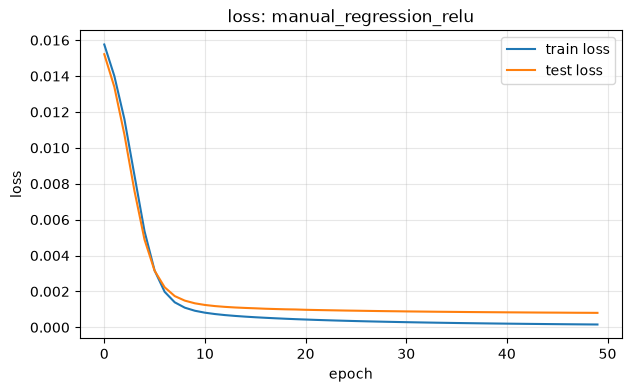

PosixPath('output/loss_manual_regression_relu.png')

In [62]:
reg_train_iter, reg_test_iter = load_regression_data(batch_size=64)
reg_net = ManualMLP([500, 128, 1], hidden_act=fun_relu)
reg_loss = torch.nn.MSELoss()
reg_history = train(
    reg_net,
    reg_train_iter,
    reg_test_iter,
    reg_loss,
    num_epochs=50,
    task_type="regression",
    implementation="manual",
    params=reg_net.params,
    lr=0.03,
)
plot_loss_curve(reg_history, "manual_regression_relu")

### 2.二分类

epoch 1, train loss 0.3853, test loss 0.0730, train acc 0.990, test acc 1.000
epoch 2, train loss 0.0337, test loss 0.0166, train acc 1.000, test acc 1.000
epoch 3, train loss 0.0116, test loss 0.0084, train acc 1.000, test acc 1.000
epoch 4, train loss 0.0067, test loss 0.0054, train acc 1.000, test acc 1.000
epoch 5, train loss 0.0046, test loss 0.0039, train acc 1.000, test acc 1.000
epoch 6, train loss 0.0034, test loss 0.0031, train acc 1.000, test acc 1.000
epoch 7, train loss 0.0027, test loss 0.0025, train acc 1.000, test acc 1.000
epoch 8, train loss 0.0023, test loss 0.0021, train acc 1.000, test acc 1.000
epoch 9, train loss 0.0019, test loss 0.0018, train acc 1.000, test acc 1.000
epoch 10, train loss 0.0017, test loss 0.0016, train acc 1.000, test acc 1.000
epoch 11, train loss 0.0015, test loss 0.0014, train acc 1.000, test acc 1.000
epoch 12, train loss 0.0013, test loss 0.0013, train acc 1.000, test acc 1.000
epoch 13, train loss 0.0012, test loss 0.0011, train acc 1.00

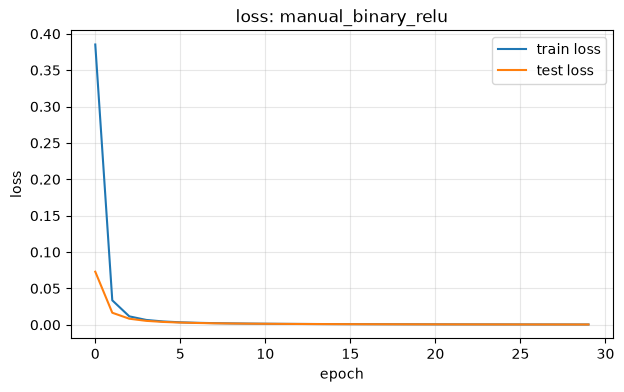

PosixPath('output/loss_manual_binary_relu.png')

In [49]:
bin_train_iter, bin_test_iter = load_binary_classification_data(batch_size=64)
bin_net = ManualMLP([200, 128, 1], hidden_act=fun_relu)
bin_loss = torch.nn.BCEWithLogitsLoss()
bin_history = train(
    bin_net, bin_train_iter, bin_test_iter,
    bin_loss, num_epochs=30,
    task_type="binary",
    implementation="manual",
    params=bin_net.params,
    lr=0.01,
)
plot_loss_curve(bin_history, "manual_binary_relu")

### 3.多分类

epoch 1, train loss 0.7125, test loss 0.3266, train acc 0.822, test acc 0.906
epoch 2, train loss 0.3055, test loss 0.2684, train acc 0.913, test acc 0.925
epoch 3, train loss 0.2516, test loss 0.2233, train acc 0.928, test acc 0.938
epoch 4, train loss 0.2135, test loss 0.1933, train acc 0.940, test acc 0.942
epoch 5, train loss 0.1854, test loss 0.1718, train acc 0.948, test acc 0.950
epoch 6, train loss 0.1635, test loss 0.1526, train acc 0.954, test acc 0.954
epoch 7, train loss 0.1459, test loss 0.1386, train acc 0.959, test acc 0.959
epoch 8, train loss 0.1311, test loss 0.1280, train acc 0.963, test acc 0.963
epoch 9, train loss 0.1189, test loss 0.1242, train acc 0.967, test acc 0.964
epoch 10, train loss 0.1089, test loss 0.1107, train acc 0.970, test acc 0.968
epoch 11, train loss 0.1000, test loss 0.1055, train acc 0.972, test acc 0.969
epoch 12, train loss 0.0925, test loss 0.1006, train acc 0.975, test acc 0.970
epoch 13, train loss 0.0860, test loss 0.0982, train acc 0.97

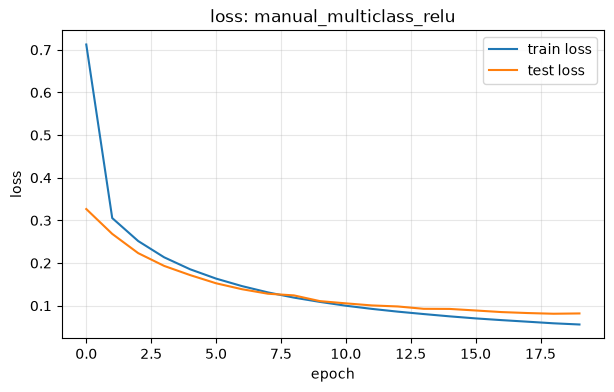

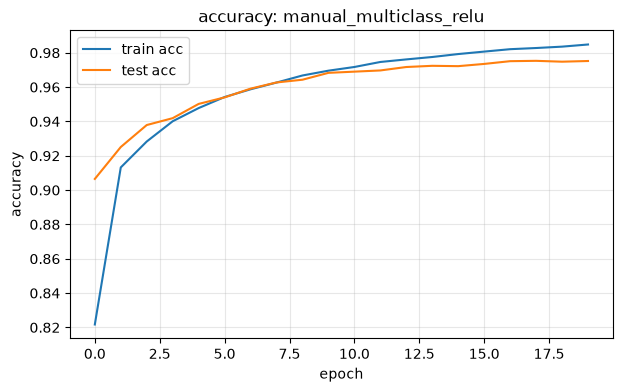

PosixPath('output/acc_manual_multiclass_relu.png')

In [65]:
mnist_train_iter, mnist_test_iter = load_mnist_data(batch_size=128)
mnist_net = ManualMLP([784, 256, 10], hidden_act=fun_relu)
mnist_loss = torch.nn.CrossEntropyLoss()
mnist_history = train(
    mnist_net,
    mnist_train_iter,
    mnist_test_iter,
    mnist_loss,
    num_epochs=20,
    task_type="multiclass",
    implementation="manual",
    params=mnist_net.params,
    lr=0.1,
)
task = "manual_multiclass_relu"
plot_loss_curve(mnist_history, task)
plot_acc_curve(mnist_history, task)

### 4.多分类任务上手动实现Dropout和L2正则化

epoch 1, train loss 0.7879, test loss 0.3322, train acc 0.783, test acc 0.909
epoch 2, train loss 0.3543, test loss 0.2547, train acc 0.901, test acc 0.930
epoch 3, train loss 0.2871, test loss 0.2128, train acc 0.920, test acc 0.942
epoch 4, train loss 0.2463, test loss 0.1884, train acc 0.932, test acc 0.948
epoch 5, train loss 0.2193, test loss 0.1650, train acc 0.940, test acc 0.954
epoch 6, train loss 0.2008, test loss 0.1501, train acc 0.945, test acc 0.959
epoch 7, train loss 0.1851, test loss 0.1432, train acc 0.949, test acc 0.961
epoch 8, train loss 0.1737, test loss 0.1328, train acc 0.953, test acc 0.965
epoch 9, train loss 0.1640, test loss 0.1247, train acc 0.957, test acc 0.966
epoch 10, train loss 0.1561, test loss 0.1186, train acc 0.958, test acc 0.967
epoch 11, train loss 0.1472, test loss 0.1131, train acc 0.960, test acc 0.970
epoch 12, train loss 0.1420, test loss 0.1105, train acc 0.963, test acc 0.970
epoch 13, train loss 0.1365, test loss 0.1093, train acc 0.96

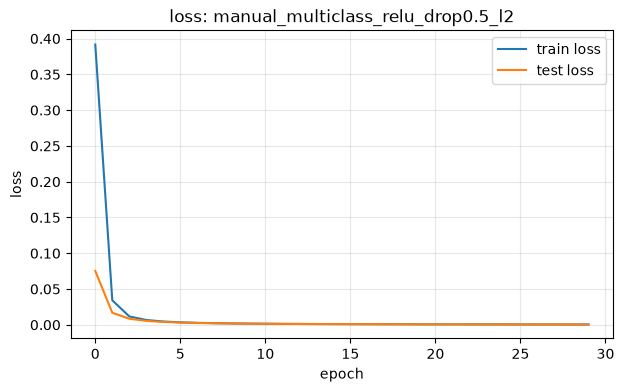

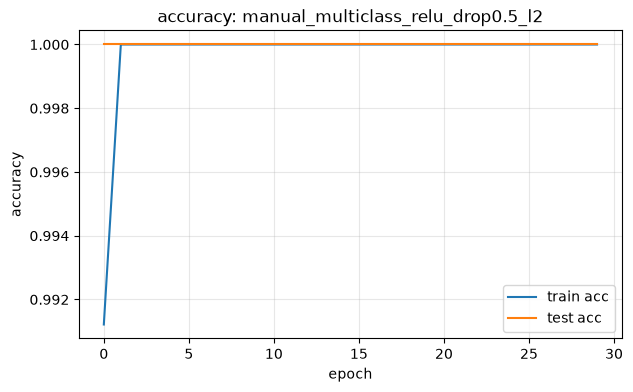

PosixPath('output/acc_manual_multiclass_relu_drop0.5_l2.png')

In [ ]:
# mnist_train_iter, mnist_test_iter = load_mnist_data(batch_size=128)
# mnist_net = ManualMLP([784, 256, 10], hidden_act=fun_relu, dropout=0.5)
# l2_loss = make_l2_loss(torch.nn.CrossEntropyLoss(), mnist_net.params, lambd=1e-4)
# mnist_history = train(
#     mnist_net,
#     mnist_train_iter,
#     mnist_test_iter,
#     l2_loss,
#     num_epochs=30,
#     task_type="multiclass",
#     implementation="manual",
#     params=mnist_net.params,
#     lr=0.1,
# )
# task = "manual_multiclass_relu_drop0.5_lambd1e-4"
# plot_loss_curve(bin_history, task)
# plot_acc_curve(bin_history, task)

## 利用torch.nn实现前馈神经网络解决上述回归、二分类、多分类任务

### 1.回归

epoch 1, train loss 0.0274, test loss 0.0175
epoch 2, train loss 0.0128, test loss 0.0124
epoch 3, train loss 0.0093, test loss 0.0100
epoch 4, train loss 0.0074, test loss 0.0084
epoch 5, train loss 0.0060, test loss 0.0072
epoch 6, train loss 0.0050, test loss 0.0063
epoch 7, train loss 0.0042, test loss 0.0057
epoch 8, train loss 0.0037, test loss 0.0051
epoch 9, train loss 0.0033, test loss 0.0048
epoch 10, train loss 0.0030, test loss 0.0044
epoch 11, train loss 0.0027, test loss 0.0042
epoch 12, train loss 0.0025, test loss 0.0040
epoch 13, train loss 0.0024, test loss 0.0038
epoch 14, train loss 0.0022, test loss 0.0036
epoch 15, train loss 0.0021, test loss 0.0035
epoch 16, train loss 0.0020, test loss 0.0034
epoch 17, train loss 0.0019, test loss 0.0033
epoch 18, train loss 0.0018, test loss 0.0032
epoch 19, train loss 0.0018, test loss 0.0031
epoch 20, train loss 0.0017, test loss 0.0030
epoch 21, train loss 0.0016, test loss 0.0029
epoch 22, train loss 0.0016, test loss 0.00

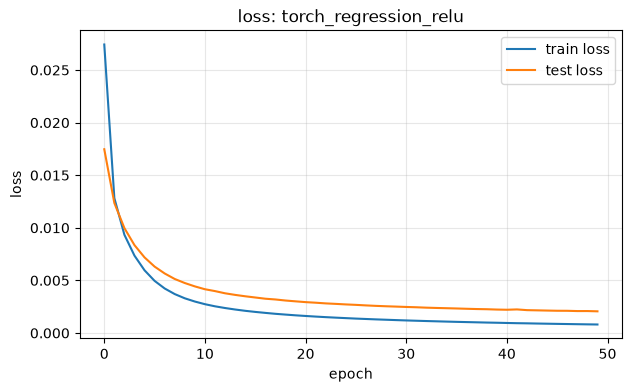

PosixPath('output/loss_torch_regression_relu.png')

In [63]:
reg_train_iter, reg_test_iter = load_regression_data(batch_size=64)

torch_reg_net = TorchMLP(
    layer_sizes=[500, 64, 1],
    activation="relu",
)

torch_reg_loss = nn.MSELoss()

torch_reg_optimizer = torch.optim.SGD(
    torch_reg_net.parameters(),
    lr=0.03,
)

torch_reg_history = train(
    torch_reg_net,
    reg_train_iter,
    reg_test_iter,
    torch_reg_loss,
    num_epochs=50,
    task_type="regression",
    implementation="torch",
    optimizer=torch_reg_optimizer,
)

plot_loss_curve(torch_reg_history, "torch_regression_relu")

### 2.二分类

epoch 1, train loss 0.2012, test loss 0.0394, train acc 0.986, test acc 1.000
epoch 2, train loss 0.0223, test loss 0.0132, train acc 1.000, test acc 1.000
epoch 3, train loss 0.0098, test loss 0.0074, train acc 1.000, test acc 1.000
epoch 4, train loss 0.0060, test loss 0.0050, train acc 1.000, test acc 1.000
epoch 5, train loss 0.0043, test loss 0.0037, train acc 1.000, test acc 1.000
epoch 6, train loss 0.0033, test loss 0.0030, train acc 1.000, test acc 1.000
epoch 7, train loss 0.0027, test loss 0.0024, train acc 1.000, test acc 1.000
epoch 8, train loss 0.0022, test loss 0.0021, train acc 1.000, test acc 1.000
epoch 9, train loss 0.0019, test loss 0.0018, train acc 1.000, test acc 1.000
epoch 10, train loss 0.0017, test loss 0.0016, train acc 1.000, test acc 1.000
epoch 11, train loss 0.0015, test loss 0.0014, train acc 1.000, test acc 1.000
epoch 12, train loss 0.0013, test loss 0.0013, train acc 1.000, test acc 1.000
epoch 13, train loss 0.0012, test loss 0.0011, train acc 1.00

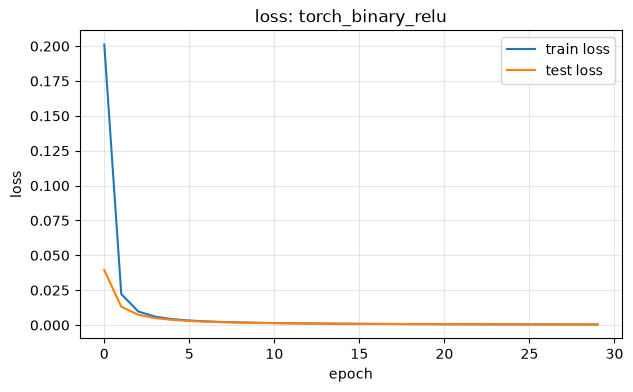

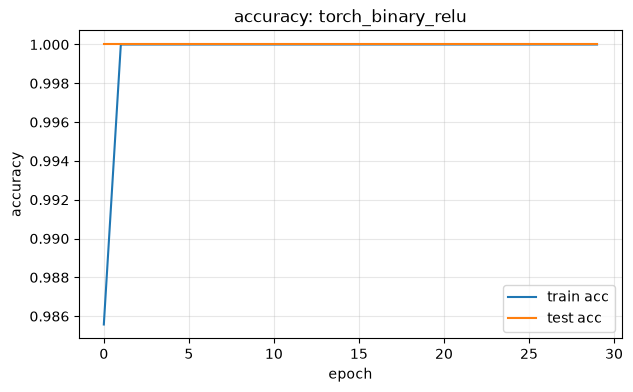

PosixPath('output/acc_torch_binary_relu.png')

In [53]:
bin_train_iter, bin_test_iter = load_binary_classification_data(batch_size=64)

torch_bin_net = TorchMLP(
    layer_sizes=[200, 32, 1],
    activation="relu",
)

torch_bin_loss = nn.BCEWithLogitsLoss()

torch_bin_optimizer = torch.optim.SGD(
    torch_bin_net.parameters(),
    lr=0.01,
)

torch_bin_history = train(
    torch_bin_net,
    bin_train_iter,
    bin_test_iter,
    torch_bin_loss,
    num_epochs=30,
    task_type="binary",
    implementation="torch",
    optimizer=torch_bin_optimizer,
)

task = "torch_binary_relu"
plot_loss_curve(torch_bin_history, task)
plot_acc_curve(torch_bin_history, task)

### 3.多分类

epoch 1, train loss 0.5695, test loss 0.3048, train acc 0.858, test acc 0.914
epoch 2, train loss 0.2896, test loss 0.2464, train acc 0.917, test acc 0.932
epoch 3, train loss 0.2351, test loss 0.2055, train acc 0.933, test acc 0.941
epoch 4, train loss 0.1978, test loss 0.1854, train acc 0.944, test acc 0.946
epoch 5, train loss 0.1703, test loss 0.1565, train acc 0.951, test acc 0.955
epoch 6, train loss 0.1499, test loss 0.1436, train acc 0.958, test acc 0.960
epoch 7, train loss 0.1328, test loss 0.1296, train acc 0.962, test acc 0.963
epoch 8, train loss 0.1197, test loss 0.1179, train acc 0.966, test acc 0.967
epoch 9, train loss 0.1081, test loss 0.1103, train acc 0.970, test acc 0.968
epoch 10, train loss 0.0990, test loss 0.1065, train acc 0.973, test acc 0.969
epoch 11, train loss 0.0910, test loss 0.0981, train acc 0.975, test acc 0.971
epoch 12, train loss 0.0842, test loss 0.0982, train acc 0.977, test acc 0.972
epoch 13, train loss 0.0782, test loss 0.0913, train acc 0.97

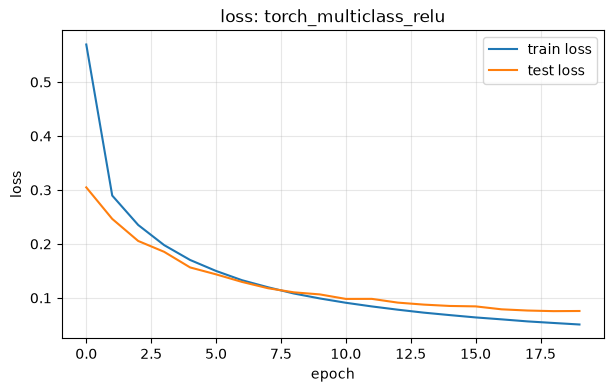

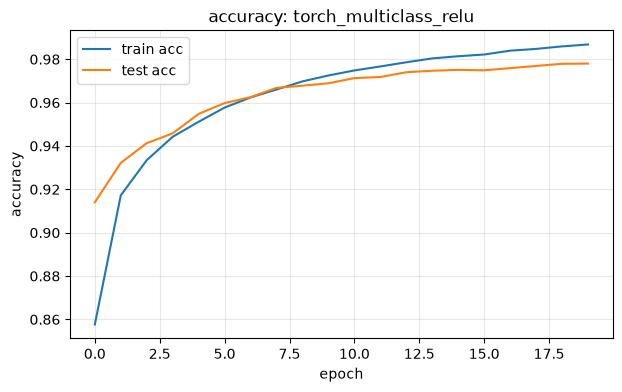

PosixPath('output/acc_torch_multiclass_relu.png')

In [54]:
mnist_train_iter, mnist_test_iter = load_mnist_data(batch_size=128)

torch_mnist_net = TorchMLP(
    layer_sizes=[784, 256, 10],
    activation="relu",
)

torch_mnist_loss = nn.CrossEntropyLoss()

torch_mnist_optimizer = torch.optim.SGD(
    torch_mnist_net.parameters(),
    lr=0.1,
)

torch_mnist_history = train(
    torch_mnist_net,
    mnist_train_iter,
    mnist_test_iter,
    torch_mnist_loss,
    num_epochs=20,
    task_type="multiclass",
    implementation="torch",
    optimizer=torch_mnist_optimizer,
)

task = "torch_multiclass_relu"
plot_loss_curve(torch_mnist_history, task)
plot_acc_curve(torch_mnist_history, task)

## 在多分类实验的基础上使用至少三种不同的激活函数

epoch 1, train loss 0.5704, test loss 0.3086, train acc 0.858, test acc 0.911
epoch 2, train loss 0.2892, test loss 0.2488, train acc 0.917, test acc 0.927
epoch 3, train loss 0.2361, test loss 0.2121, train acc 0.933, test acc 0.937
epoch 4, train loss 0.1987, test loss 0.1775, train acc 0.943, test acc 0.949
epoch 5, train loss 0.1704, test loss 0.1581, train acc 0.952, test acc 0.954
epoch 6, train loss 0.1492, test loss 0.1438, train acc 0.958, test acc 0.958
epoch 7, train loss 0.1321, test loss 0.1253, train acc 0.963, test acc 0.964
epoch 8, train loss 0.1186, test loss 0.1177, train acc 0.967, test acc 0.965
epoch 9, train loss 0.1070, test loss 0.1076, train acc 0.970, test acc 0.967
epoch 10, train loss 0.0977, test loss 0.1022, train acc 0.973, test acc 0.970
epoch 11, train loss 0.0897, test loss 0.0946, train acc 0.975, test acc 0.972
epoch 12, train loss 0.0831, test loss 0.0957, train acc 0.977, test acc 0.971
epoch 13, train loss 0.0775, test loss 0.0873, train acc 0.97

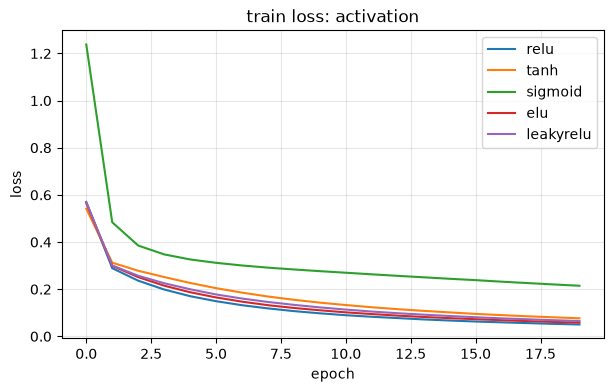

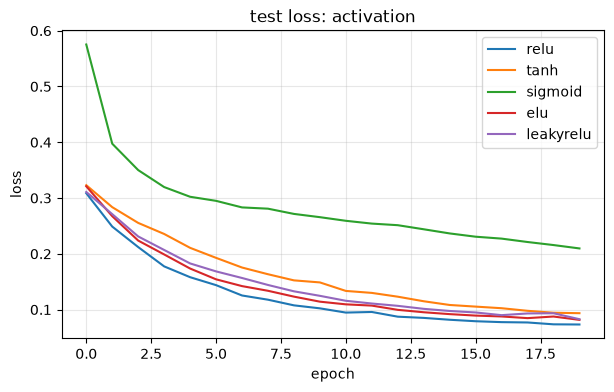

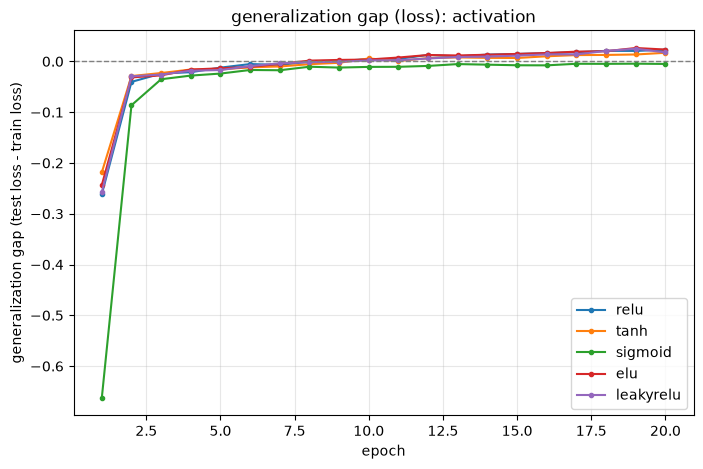

PosixPath('output/generalization_loss_activation.png')

In [77]:
mnist_train_iter, mnist_test_iter = load_mnist_data(batch_size=128)

task_list = ["relu", "tanh", "sigmoid", "elu", "leakyrelu"]
histories = []
for act in task_list:
    torch_mnist_net = TorchMLP(
        layer_sizes=[784, 256, 10],
        activation=act,
    )

    torch_mnist_loss = nn.CrossEntropyLoss()

    torch_mnist_optimizer = torch.optim.SGD(
        torch_mnist_net.parameters(),
        lr=0.1,
    )

    torch_mnist_history = train(
        torch_mnist_net,
        mnist_train_iter,
        mnist_test_iter,
        torch_mnist_loss,
        num_epochs=20,
        task_type="multiclass",
        implementation="torch",
        optimizer=torch_mnist_optimizer,
    )
    histories.append(torch_mnist_history)

name = "activation"
plot_train_test_loss_curves(histories, task_list, name)
plot_generalization_curve(histories, task_list, name)

## 对多分类任务中的模型评估隐藏层层数和隐藏单元个数对实验结果的影响

### 1.隐藏层数

epoch 1, train loss 0.5700, test loss 0.3125, train acc 0.860, test acc 0.914
epoch 2, train loss 0.2877, test loss 0.2426, train acc 0.918, test acc 0.930
epoch 3, train loss 0.2351, test loss 0.2078, train acc 0.933, test acc 0.941
epoch 4, train loss 0.1971, test loss 0.1803, train acc 0.945, test acc 0.947
epoch 5, train loss 0.1699, test loss 0.1549, train acc 0.952, test acc 0.955
epoch 6, train loss 0.1483, test loss 0.1385, train acc 0.958, test acc 0.960
epoch 7, train loss 0.1321, test loss 0.1293, train acc 0.963, test acc 0.962
epoch 8, train loss 0.1187, test loss 0.1162, train acc 0.967, test acc 0.966
epoch 9, train loss 0.1076, test loss 0.1103, train acc 0.970, test acc 0.968
epoch 10, train loss 0.0983, test loss 0.1025, train acc 0.973, test acc 0.970
epoch 11, train loss 0.0906, test loss 0.1005, train acc 0.975, test acc 0.970
epoch 12, train loss 0.0840, test loss 0.0928, train acc 0.977, test acc 0.972
epoch 13, train loss 0.0778, test loss 0.0906, train acc 0.97

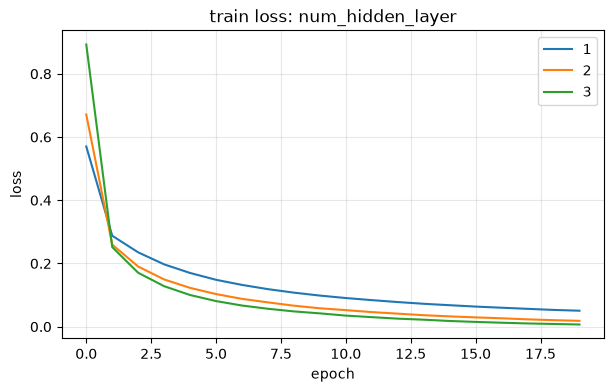

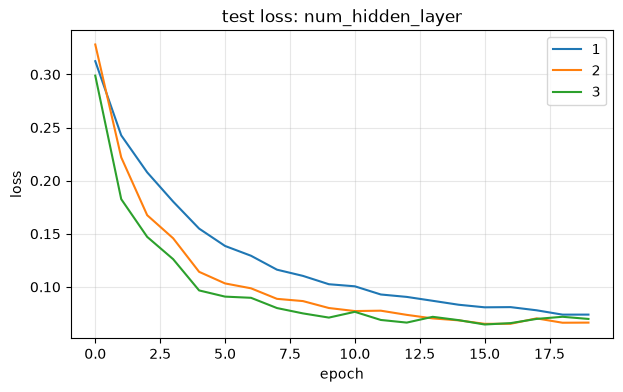

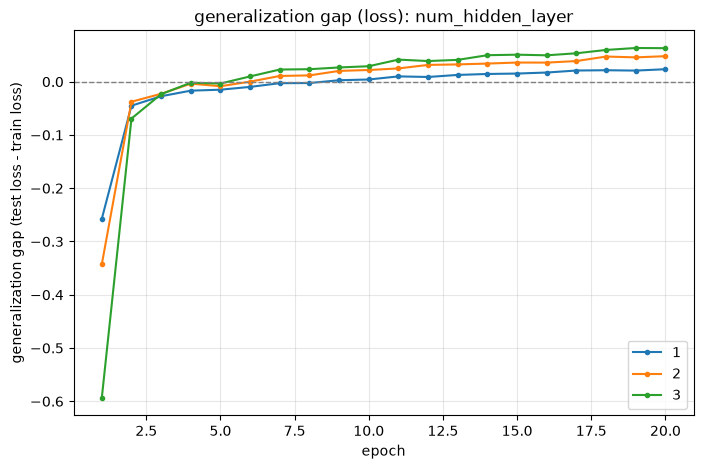

PosixPath('output/generalization_loss_num_hidden_layer.png')

In [78]:
mnist_train_iter, mnist_test_iter = load_mnist_data(batch_size=128)

num_hidden_layers = [1, 2, 3]
task_list = [str(x) for x in num_hidden_layers]

histories = []
for num_hidden_layer in num_hidden_layers:
    torch_mnist_net = TorchMLP(
        layer_sizes=[784] + [256] * num_hidden_layer + [10],
        activation="relu",
    )

    torch_mnist_loss = nn.CrossEntropyLoss()

    torch_mnist_optimizer = torch.optim.SGD(
        torch_mnist_net.parameters(),
        lr=0.1,
    )

    torch_mnist_history = train(
        torch_mnist_net,
        mnist_train_iter,
        mnist_test_iter,
        torch_mnist_loss,
        num_epochs=20,
        task_type="multiclass",
        implementation="torch",
        optimizer=torch_mnist_optimizer,
    )
    histories.append(torch_mnist_history)

name = "num_hidden_layer"
plot_train_test_loss_curves(histories, task_list, name)
plot_generalization_curve(histories, task_list, name)


### 2.隐藏层维度

epoch 1, train loss 0.5832, test loss 0.3143, train acc 0.854, test acc 0.910
epoch 2, train loss 0.2980, test loss 0.2568, train acc 0.915, test acc 0.925
epoch 3, train loss 0.2473, test loss 0.2199, train acc 0.929, test acc 0.937
epoch 4, train loss 0.2121, test loss 0.1905, train acc 0.940, test acc 0.947
epoch 5, train loss 0.1860, test loss 0.1789, train acc 0.947, test acc 0.949
epoch 6, train loss 0.1658, test loss 0.1556, train acc 0.953, test acc 0.955
epoch 7, train loss 0.1497, test loss 0.1452, train acc 0.957, test acc 0.958
epoch 8, train loss 0.1368, test loss 0.1397, train acc 0.961, test acc 0.959
epoch 9, train loss 0.1256, test loss 0.1281, train acc 0.964, test acc 0.962
epoch 10, train loss 0.1161, test loss 0.1249, train acc 0.968, test acc 0.963
epoch 11, train loss 0.1077, test loss 0.1140, train acc 0.970, test acc 0.966
epoch 12, train loss 0.1006, test loss 0.1082, train acc 0.972, test acc 0.967
epoch 13, train loss 0.0944, test loss 0.1068, train acc 0.97

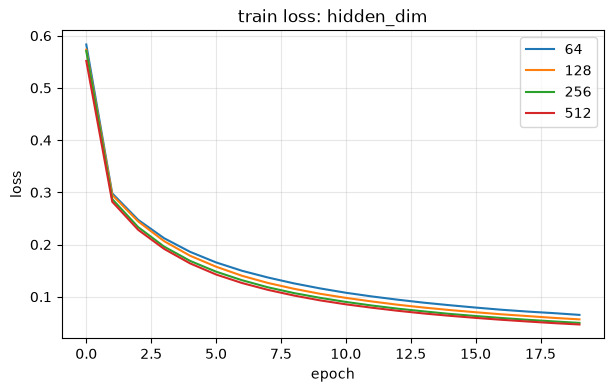

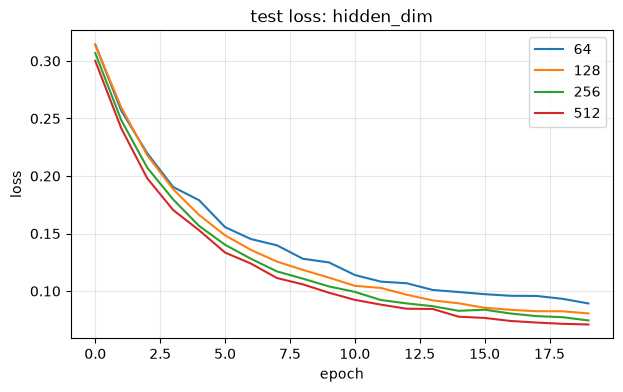

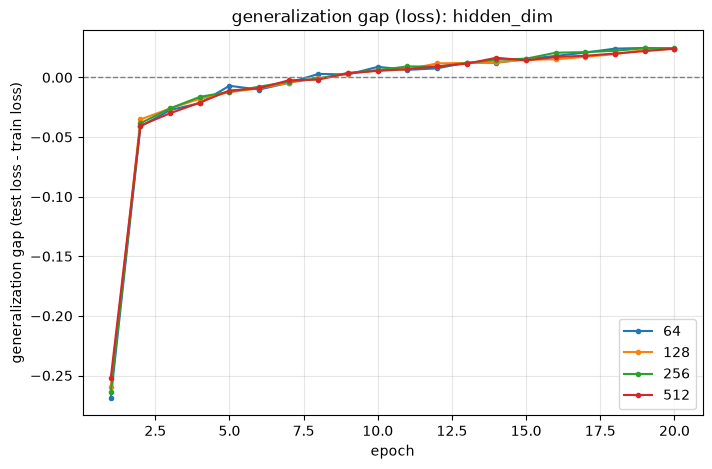

PosixPath('output/generalization_loss_hidden_dim.png')

In [79]:
mnist_train_iter, mnist_test_iter = load_mnist_data(batch_size=128)

hidden_dims = [64, 128, 256, 512]
task_list = [str(x) for x in hidden_dims]

histories = []
for hidden_dim in hidden_dims:
    torch_mnist_net = TorchMLP(
        layer_sizes=[784, hidden_dim, 10],
        activation="relu",
    )

    torch_mnist_loss = nn.CrossEntropyLoss()

    torch_mnist_optimizer = torch.optim.SGD(
        torch_mnist_net.parameters(),
        lr=0.1,
    )

    torch_mnist_history = train(
        torch_mnist_net,
        mnist_train_iter,
        mnist_test_iter,
        torch_mnist_loss,
        num_epochs=20,
        task_type="multiclass",
        implementation="torch",
        optimizer=torch_mnist_optimizer,
    )
    histories.append(torch_mnist_history)

name = "hidden_dim"
plot_train_test_loss_curves(histories, task_list, name)
plot_generalization_curve(histories, task_list, name)

## 探究不同丢弃率对实验结果的影响

epoch 1, train loss 0.5706, test loss 0.3107, train acc 0.856, test acc 0.910
epoch 2, train loss 0.2888, test loss 0.2497, train acc 0.918, test acc 0.928
epoch 3, train loss 0.2361, test loss 0.2091, train acc 0.933, test acc 0.941
epoch 4, train loss 0.1994, test loss 0.1815, train acc 0.944, test acc 0.950
epoch 5, train loss 0.1726, test loss 0.1637, train acc 0.951, test acc 0.954
epoch 6, train loss 0.1510, test loss 0.1420, train acc 0.958, test acc 0.960
epoch 7, train loss 0.1339, test loss 0.1308, train acc 0.963, test acc 0.963
epoch 8, train loss 0.1202, test loss 0.1200, train acc 0.967, test acc 0.966
epoch 9, train loss 0.1084, test loss 0.1125, train acc 0.970, test acc 0.967
epoch 10, train loss 0.0993, test loss 0.1107, train acc 0.973, test acc 0.967
epoch 11, train loss 0.0911, test loss 0.1012, train acc 0.975, test acc 0.972
epoch 12, train loss 0.0842, test loss 0.0949, train acc 0.977, test acc 0.972
epoch 13, train loss 0.0784, test loss 0.0907, train acc 0.97

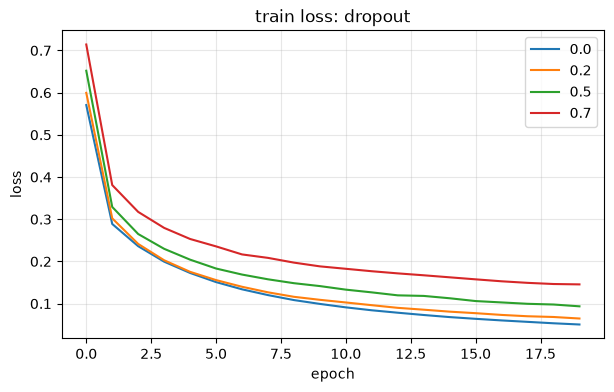

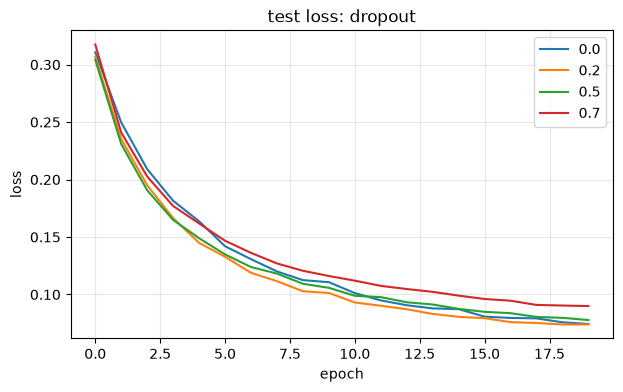

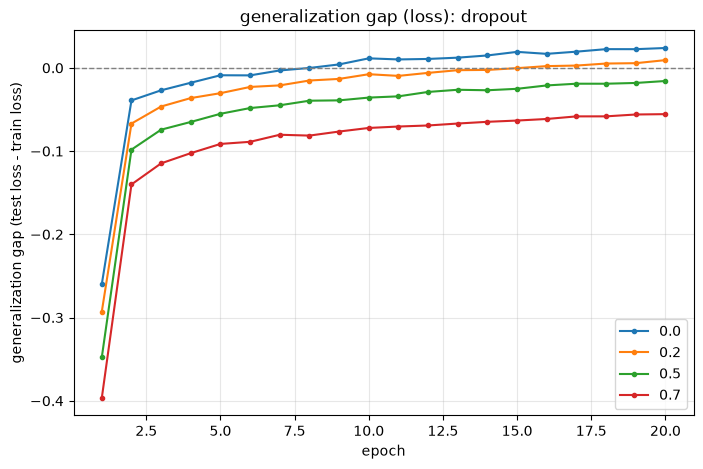

PosixPath('output/generalization_loss_dropout.png')

In [80]:
mnist_train_iter, mnist_test_iter = load_mnist_data(batch_size=128)

dropouts = [0.0, 0.2, 0.5, 0.7]
task_list = [str(x) for x in dropouts]

histories = []
for dropout in dropouts:
    torch_mnist_net = TorchMLP(
        layer_sizes=[784, 256, 10], activation="relu", dropout=dropout
    )

    torch_mnist_loss = nn.CrossEntropyLoss()

    torch_mnist_optimizer = torch.optim.SGD(
        torch_mnist_net.parameters(),
        lr=0.1,
    )

    torch_mnist_history = train(
        torch_mnist_net,
        mnist_train_iter,
        mnist_test_iter,
        torch_mnist_loss,
        num_epochs=20,
        task_type="multiclass",
        implementation="torch",
        optimizer=torch_mnist_optimizer,
    )
    histories.append(torch_mnist_history)

name = "dropout"
plot_train_test_loss_curves(histories, task_list, name)
plot_generalization_curve(histories, task_list, name)

## 探究惩罚项的权重对实验结果的影响

epoch 1, train loss 0.5711, test loss 0.3019, train acc 0.859, test acc 0.917
epoch 2, train loss 0.2828, test loss 0.2424, train acc 0.920, test acc 0.930
epoch 3, train loss 0.2293, test loss 0.2022, train acc 0.935, test acc 0.942
epoch 4, train loss 0.1934, test loss 0.1763, train acc 0.945, test acc 0.950
epoch 5, train loss 0.1665, test loss 0.1513, train acc 0.953, test acc 0.956
epoch 6, train loss 0.1461, test loss 0.1381, train acc 0.959, test acc 0.960
epoch 7, train loss 0.1295, test loss 0.1290, train acc 0.964, test acc 0.964
epoch 8, train loss 0.1169, test loss 0.1199, train acc 0.968, test acc 0.965
epoch 9, train loss 0.1060, test loss 0.1099, train acc 0.971, test acc 0.969
epoch 10, train loss 0.0973, test loss 0.1043, train acc 0.973, test acc 0.970
epoch 11, train loss 0.0893, test loss 0.0980, train acc 0.975, test acc 0.971
epoch 12, train loss 0.0831, test loss 0.0925, train acc 0.977, test acc 0.973
epoch 13, train loss 0.0770, test loss 0.0902, train acc 0.97

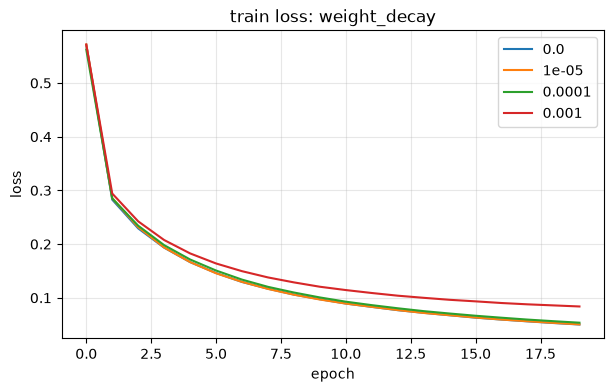

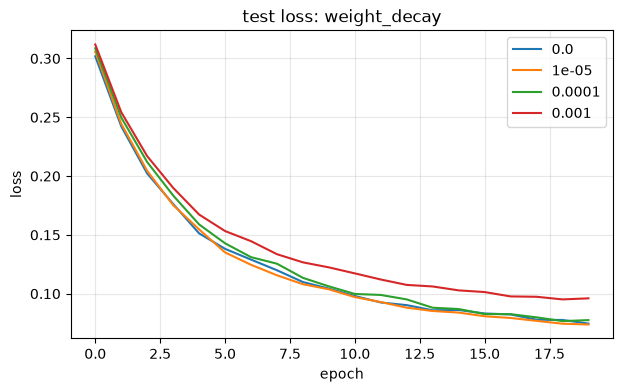

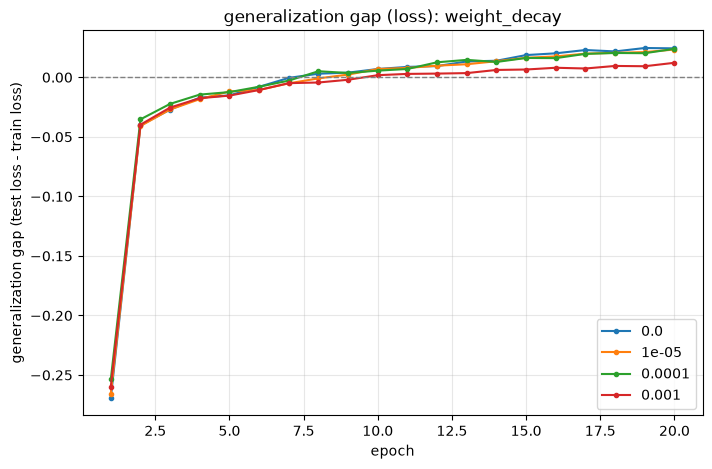

PosixPath('output/generalization_loss_weight_decay.png')

In [81]:
mnist_train_iter, mnist_test_iter = load_mnist_data(batch_size=128)

weight_decays = [0.0, 1e-5, 1e-4, 1e-3]
task_list = [str(x) for x in weight_decays]

histories = []
for weight_decay in weight_decays:
    torch_mnist_net = TorchMLP(layer_sizes=[784, 256, 10], activation="relu")

    torch_mnist_loss = nn.CrossEntropyLoss()

    torch_mnist_optimizer = torch.optim.SGD(
        torch_mnist_net.parameters(), lr=0.1, weight_decay=weight_decay
    )

    torch_mnist_history = train(
        torch_mnist_net,
        mnist_train_iter,
        mnist_test_iter,
        torch_mnist_loss,
        num_epochs=20,
        task_type="multiclass",
        implementation="torch",
        optimizer=torch_mnist_optimizer,
    )
    histories.append(torch_mnist_history)

name = "weight_decay"
plot_train_test_loss_curves(histories, task_list, name)
plot_generalization_curve(histories, task_list, name)


## 10折交叉验证评估实验结果

### 1.K折数据加载

In [24]:
def make_data_loader(X, y, batch_size, shuffle):
    dataset = TensorDataset(X, y)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
    )


def get_kfold_data(k, i, X, y):
    assert 0 <= i < k, "fold index 超出范围"

    fold_size = X.shape[0] // k
    val_start = i * fold_size

    if i != k - 1:
        val_end = (i + 1) * fold_size
        X_valid, y_valid = X[val_start:val_end], y[val_start:val_end]
        X_train = torch.cat((X[:val_start], X[val_end:]), dim=0)
        y_train = torch.cat((y[:val_start], y[val_end:]), dim=0)
    else:
        X_valid, y_valid = X[val_start:], y[val_start:]
        X_train = X[:val_start]
        y_train = y[:val_start]

    return X_train, y_train, X_valid, y_valid

### 2.结果保存

In [25]:
def summarize_kfold_results(fold_results):
    df = pd.DataFrame(fold_results)

    avg_row = {"fold": "avg"}
    for col in df.columns:
        if col != "fold":
            avg_row[col] = df[col].mean()

    df = pd.concat([df, pd.DataFrame([avg_row])], ignore_index=True)
    return df


def run_torch_kfold(
    X,
    y,
    k,
    build_model,
    loss_fn,
    task_type,
    batch_size,
    num_epochs,
    lr,
    weight_decay=0.0,
    seed=42,
):
    fold_results = []

    for fold_idx in range(k):
        torch.manual_seed(seed + fold_idx)

        X_train, y_train, X_valid, y_valid = get_kfold_data(k, fold_idx, X, y)

        train_iter = make_data_loader(
            X_train,
            y_train,
            batch_size=batch_size,
            shuffle=True,
        )
        valid_iter = make_data_loader(
            X_valid,
            y_valid,
            batch_size=batch_size,
            shuffle=False,
        )

        net = build_model()
        optimizer = torch.optim.SGD(
            net.parameters(),
            lr=lr,
            weight_decay=weight_decay,
        )

        history = train(
            net,
            train_iter,
            valid_iter,
            loss_fn,
            num_epochs=num_epochs,
            task_type=task_type,
            implementation="torch",
            optimizer=optimizer,
        )

        result = {
            "fold": fold_idx + 1,
            "final_train_loss": history["train_loss"][-1],
            "final_valid_loss": history["test_loss"][-1],
            "best_valid_loss": min(history["test_loss"]),
        }

        if task_type != "regression":
            result["final_train_acc"] = history["train_accuracy"][-1]
            result["final_valid_acc"] = history["test_accuracy"][-1]
            result["best_valid_acc"] = max(history["test_accuracy"])

        fold_results.append(result)

    return summarize_kfold_results(fold_results)


def save_and_display_kfold_results(df, file_name, output_dir="./output"):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    save_path = output_dir / file_name
    df.to_csv(save_path, index=False)

    display(df)

    return save_path

### 3.回归

In [26]:
# ============================================================
# 1. 回归任务：K 折数据
# ============================================================


def build_regression_kfold_dataset(noise_std=0.01, seed=42):
    generator = torch.Generator().manual_seed(seed)

    num_samples = 10000
    num_features = 500

    X = torch.randn(num_samples, num_features, generator=generator)
    noise = torch.randn(num_samples, 1, generator=generator) * noise_std
    y = 0.028 + 0.0056 * X.sum(dim=1, keepdim=True) + noise

    indices = torch.randperm(num_samples, generator=generator)
    X = X[indices]
    y = y[indices]

    return X, y


def load_regression_kfold_data(
    k,
    fold_idx,
    batch_size=64,
    noise_std=0.01,
    seed=42,
):
    X, y = build_regression_kfold_dataset(
        noise_std=noise_std,
        seed=seed,
    )

    X_train, y_train, X_valid, y_valid = get_kfold_data(k, fold_idx, X, y)

    train_iter = make_data_loader(X_train, y_train, batch_size=batch_size, shuffle=True)
    valid_iter = make_data_loader(
        X_valid, y_valid, batch_size=batch_size, shuffle=False
    )

    return train_iter, valid_iter


X_reg, y_reg = build_regression_kfold_dataset(
    noise_std=0.01,
    seed=42,
)

reg_kfold_df = run_torch_kfold(
    X=X_reg,
    y=y_reg,
    k=10,
    build_model=lambda: TorchMLP(
        layer_sizes=[500, 64, 1],
        activation="relu",
    ),
    loss_fn=nn.MSELoss(),
    task_type="regression",
    batch_size=64,
    num_epochs=50,
    lr=0.03,
    weight_decay=0.0,
    seed=42,
)

save_and_display_kfold_results(
    reg_kfold_df,
    "kfold_regression_torch.csv",
)


epoch 1, train loss 0.0295, test loss 0.0145
epoch 2, train loss 0.0113, test loss 0.0096
epoch 3, train loss 0.0077, test loss 0.0075
epoch 4, train loss 0.0059, test loss 0.0061
epoch 5, train loss 0.0047, test loss 0.0053
epoch 6, train loss 0.0039, test loss 0.0047
epoch 7, train loss 0.0034, test loss 0.0043
epoch 8, train loss 0.0031, test loss 0.0040
epoch 9, train loss 0.0028, test loss 0.0037
epoch 10, train loss 0.0026, test loss 0.0035
epoch 11, train loss 0.0024, test loss 0.0033
epoch 12, train loss 0.0022, test loss 0.0032
epoch 13, train loss 0.0021, test loss 0.0031
epoch 14, train loss 0.0020, test loss 0.0030
epoch 15, train loss 0.0019, test loss 0.0029
epoch 16, train loss 0.0018, test loss 0.0028
epoch 17, train loss 0.0017, test loss 0.0027
epoch 18, train loss 0.0016, test loss 0.0026
epoch 19, train loss 0.0016, test loss 0.0026
epoch 20, train loss 0.0015, test loss 0.0025
epoch 21, train loss 0.0015, test loss 0.0025
epoch 22, train loss 0.0014, test loss 0.00

,fold,final_train_loss,final_valid_loss,best_valid_loss
0,1,0.000756,0.001702,0.001702
1,2,0.000750,0.001801,0.001801
2,3,0.000748,0.001721,0.001721
3,4,0.000750,0.001588,0.001588
4,5,0.000774,0.001647,0.001647
5,6,0.000761,0.001517,0.001517
6,7,0.000766,0.001598,0.001598
7,8,0.000752,0.001648,0.001648
8,9,0.000743,0.001601,0.001601
9,10,0.000762,0.001733,0.001733


PosixPath('output/kfold_regression_torch.csv')

### 4.二分类

In [28]:
# ============================================================
# 2. 二分类任务：K 折数据
# ============================================================


def build_binary_kfold_dataset(
    class_mean=0.5,
    class_std=1.0,
    seed=42,
):
    generator = torch.Generator().manual_seed(seed)

    samples_per_class = 10000
    num_features = 200

    X_class0 = (
        torch.randn(samples_per_class, num_features, generator=generator) * class_std
        - class_mean
    )
    y_class0 = torch.zeros(samples_per_class, 1, dtype=torch.float32)

    X_class1 = (
        torch.randn(samples_per_class, num_features, generator=generator) * class_std
        + class_mean
    )
    y_class1 = torch.ones(samples_per_class, 1, dtype=torch.float32)

    X = torch.cat([X_class0, X_class1], dim=0)
    y = torch.cat([y_class0, y_class1], dim=0)

    indices = torch.randperm(X.shape[0], generator=generator)
    X = X[indices]
    y = y[indices]

    return X, y


def load_binary_kfold_data(
    k,
    fold_idx,
    batch_size=64,
    class_mean=0.5,
    class_std=1.0,
    seed=42,
):
    X, y = build_binary_kfold_dataset(
        class_mean=class_mean,
        class_std=class_std,
        seed=seed,
    )

    X_train, y_train, X_valid, y_valid = get_kfold_data(k, fold_idx, X, y)

    train_iter = make_data_loader(X_train, y_train, batch_size=batch_size, shuffle=True)
    valid_iter = make_data_loader(
        X_valid, y_valid, batch_size=batch_size, shuffle=False
    )

    return train_iter, valid_iter


X_bin, y_bin = build_binary_kfold_dataset(
    class_mean=0.5,
    class_std=1.0,
    seed=42,
)

bin_kfold_df = run_torch_kfold(
    X=X_bin,
    y=y_bin,
    k=10,
    build_model=lambda: TorchMLP(
        layer_sizes=[200, 32, 1],
        activation="relu",
    ),
    loss_fn=nn.BCEWithLogitsLoss(),
    task_type="binary",
    batch_size=64,
    num_epochs=30,
    lr=0.01,
    weight_decay=0.0,
    seed=42,
)

save_and_display_kfold_results(
    bin_kfold_df,
    "kfold_binary_torch.csv",
)

epoch 1, train loss 0.1564, test loss 0.0236, train acc 0.975, test acc 1.000
epoch 2, train loss 0.0141, test loss 0.0086, train acc 1.000, test acc 1.000
epoch 3, train loss 0.0066, test loss 0.0050, train acc 1.000, test acc 1.000
epoch 4, train loss 0.0042, test loss 0.0034, train acc 1.000, test acc 1.000
epoch 5, train loss 0.0030, test loss 0.0026, train acc 1.000, test acc 1.000
epoch 6, train loss 0.0024, test loss 0.0021, train acc 1.000, test acc 1.000
epoch 7, train loss 0.0019, test loss 0.0017, train acc 1.000, test acc 1.000
epoch 8, train loss 0.0016, test loss 0.0014, train acc 1.000, test acc 1.000
epoch 9, train loss 0.0014, test loss 0.0013, train acc 1.000, test acc 1.000
epoch 10, train loss 0.0012, test loss 0.0011, train acc 1.000, test acc 1.000
epoch 11, train loss 0.0011, test loss 0.0010, train acc 1.000, test acc 1.000
epoch 12, train loss 0.0010, test loss 0.0009, train acc 1.000, test acc 1.000
epoch 13, train loss 0.0009, test loss 0.0008, train acc 1.00

,fold,final_train_loss,final_valid_loss,best_valid_loss,final_train_acc,final_valid_acc,best_valid_acc
0,1,0.000325,0.000311,0.000311,1.0,1.0,1.0
1,2,0.000324,0.000344,0.000344,1.0,1.0,1.0
2,3,0.000321,0.000318,0.000318,1.0,1.0,1.0
3,4,0.000325,0.000358,0.000358,1.0,1.0,1.0
4,5,0.000324,0.000338,0.000338,1.0,1.0,1.0
5,6,0.000323,0.000359,0.000359,1.0,1.0,1.0
6,7,0.000323,0.000290,0.000290,1.0,1.0,1.0
7,8,0.000322,0.000332,0.000332,1.0,1.0,1.0
8,9,0.000325,0.000305,0.000305,1.0,1.0,1.0
9,10,0.000323,0.000316,0.000316,1.0,1.0,1.0


PosixPath('output/kfold_binary_torch.csv')

### 5.多分类

In [29]:
# ============================================================
# 3. MNIST 多分类任务：K 折数据
# 默认只对训练集 60000 样本做 10 折交叉验证
# ============================================================


def build_mnist_kfold_dataset(data_root="../data"):
    train_dataset = datasets.MNIST(
        root=data_root,
        train=True,
        download=True,
    )

    X = train_dataset.data.float().reshape(-1, 784) / 255.0
    y = train_dataset.targets.long()

    return X, y


def load_mnist_kfold_data(
    k,
    fold_idx,
    batch_size=128,
    data_root="../data",
):
    X, y = build_mnist_kfold_dataset(data_root=data_root)

    X_train, y_train, X_valid, y_valid = get_kfold_data(k, fold_idx, X, y)

    train_iter = make_data_loader(X_train, y_train, batch_size=batch_size, shuffle=True)
    valid_iter = make_data_loader(
        X_valid, y_valid, batch_size=batch_size, shuffle=False
    )

    return train_iter, valid_iter


X_mnist, y_mnist = build_mnist_kfold_dataset(data_root="../data")

mnist_kfold_df = run_torch_kfold(
    X=X_mnist,
    y=y_mnist,
    k=10,
    build_model=lambda: TorchMLP(
        layer_sizes=[784, 256, 256, 256, 10], activation="relu", dropout=0.2
    ),
    loss_fn=nn.CrossEntropyLoss(),
    task_type="multiclass",
    batch_size=128,
    num_epochs=16,
    lr=0.1,
    weight_decay=1e-5,
    seed=42,
)

save_and_display_kfold_results(
    mnist_kfold_df,
    "kfold_mnist_torch.csv",
)

epoch 1, train loss 1.0414, test loss 0.3304, train acc 0.668, test acc 0.907
epoch 2, train loss 0.3221, test loss 0.2092, train acc 0.904, test acc 0.943
epoch 3, train loss 0.2157, test loss 0.1483, train acc 0.936, test acc 0.956
epoch 4, train loss 0.1666, test loss 0.1229, train acc 0.951, test acc 0.966
epoch 5, train loss 0.1378, test loss 0.0992, train acc 0.960, test acc 0.970
epoch 6, train loss 0.1173, test loss 0.0972, train acc 0.965, test acc 0.970
epoch 7, train loss 0.1039, test loss 0.0886, train acc 0.969, test acc 0.975
epoch 8, train loss 0.0940, test loss 0.0840, train acc 0.972, test acc 0.975
epoch 9, train loss 0.0827, test loss 0.0767, train acc 0.975, test acc 0.976
epoch 10, train loss 0.0745, test loss 0.0728, train acc 0.977, test acc 0.979
epoch 11, train loss 0.0695, test loss 0.0720, train acc 0.978, test acc 0.978
epoch 12, train loss 0.0632, test loss 0.0726, train acc 0.980, test acc 0.978
epoch 13, train loss 0.0567, test loss 0.0755, train acc 0.98

,fold,final_train_loss,final_valid_loss,best_valid_loss,final_train_acc,final_valid_acc,best_valid_acc
0,1,0.047053,0.067408,0.067408,0.985444,0.980667,0.980667
1,2,0.043982,0.075220,0.067886,0.986500,0.980667,0.981500
2,3,0.047527,0.064996,0.064996,0.985333,0.979667,0.979667
3,4,0.045449,0.072524,0.072524,0.985278,0.977000,0.977000
4,5,0.047729,0.083974,0.079460,0.985111,0.976000,0.976667
5,6,0.047130,0.076005,0.074107,0.985074,0.978167,0.978500
6,7,0.043554,0.085159,0.083813,0.986407,0.976167,0.976167
7,8,0.045321,0.101068,0.089973,0.985759,0.971167,0.974167
8,9,0.043307,0.090746,0.088839,0.986704,0.973000,0.973833
9,10,0.043744,0.061228,0.057964,0.986389,0.981500,0.983000


PosixPath('output/kfold_mnist_torch.csv')